In [1]:
import cv2
import os

os.makedirs("captured", exist_ok=True)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

if face_cascade.empty():
    raise Exception("Could not load Haar Cascade XML file.")

In [2]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise Exception("Cannot open webcam")

print("Press 'S' to capture")
print("Press 'Q' to quit")

Press 'S' to capture
Press 'Q' to quit


In [3]:
captured = False

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.2,
        minNeighbors=5,
        minSize=(120,120)
    )

    face_crop = None

    for (x, y, w, h) in faces:

        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)

        face_crop = frame[y:y+h,x:x+w]

    cv2.putText(
        frame,
        "Press S = Capture | Q = Quit",
        (10,30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0,255,0),
        2
    )

    cv2.imshow("AI Skin Scanner", frame)

    key = cv2.waitKey(1) & 0xFF

    if key == ord('s'):

        if face_crop is not None:

            face_crop = cv2.resize(face_crop,(224,224))

            cv2.imwrite("captured/current_face.jpg", face_crop)

            print("Face Saved!")

            captured = True

            break

        else:

            print("No Face Detected")

    elif key == ord('q'):

        break

cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

if captured:
    print("Capture Complete")

Face Saved!
Capture Complete


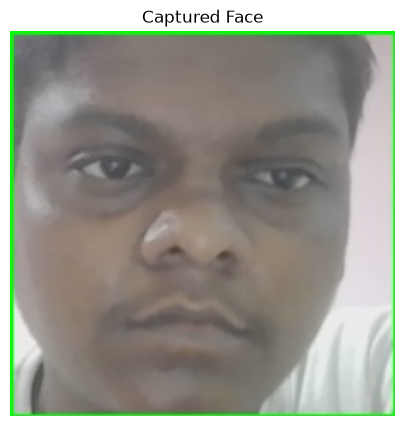

In [4]:
import matplotlib.pyplot as plt

img = cv2.imread("captured/current_face.jpg")

img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title("Captured Face")
plt.show()